<a href="https://colab.research.google.com/github/Sameekshaingole/fraud-detection-federated-learning/blob/main/notebooks/Federated_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FEDERATED LEARNING (WITH 3 BANKS)


Mounted at /content/drive
Libraries imported successfully!
DATA LOADED
X_train shape : (555902, 224)
X_test shape  : (118108, 224)
Fraud in train: 100000
Fraud in test : 4133

Creating 3 realistic banks...

Bank distribution:
Bank A: (190006, 224) | Fraud: 35000 | Not Fraud: 155006
Bank B: (183448, 224) | Fraud: 33000 | Not Fraud: 150448
Bank C: (182448, 224) | Fraud: 32000 | Not Fraud: 150448

Local model training ready!
Federated prediction ready!

Starting Federated Learning...

Round 1/5
----------------------------------------
  Bank A trained successfully
  Bank B trained successfully
  Bank C trained successfully
  Accuracy        : 0.9271
  Precision       : 0.2598
  Recall          : 0.5865
  F1 Score        : 0.3601
  ROC-AUC         : 0.868
  Predicted Fraud : 9330
  Probability Stats:
    Min   : 0.0079
    25%   : 0.0526
    50%   : 0.1101
    75%   : 0.2204
    Max   : 0.9889
    Mean  : 0.1724

Round 2/5
----------------------------------------
  Bank A trained successfu

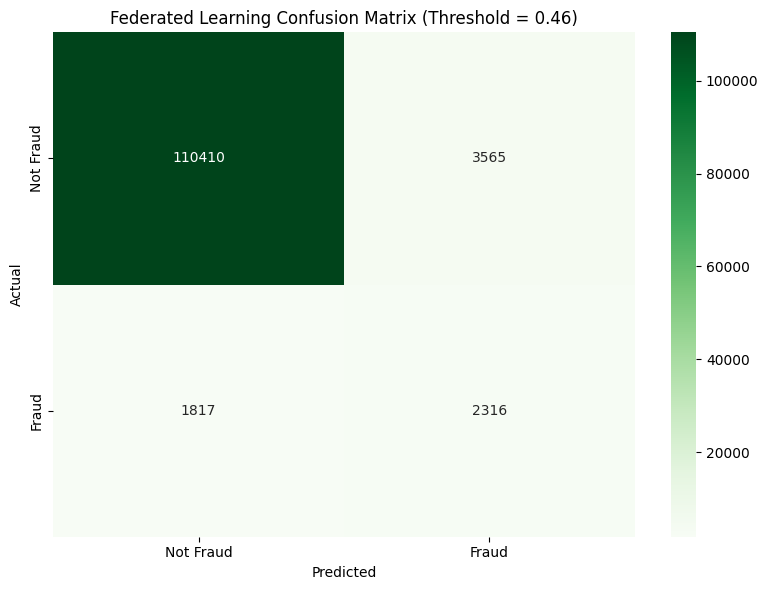

Confusion matrix saved!


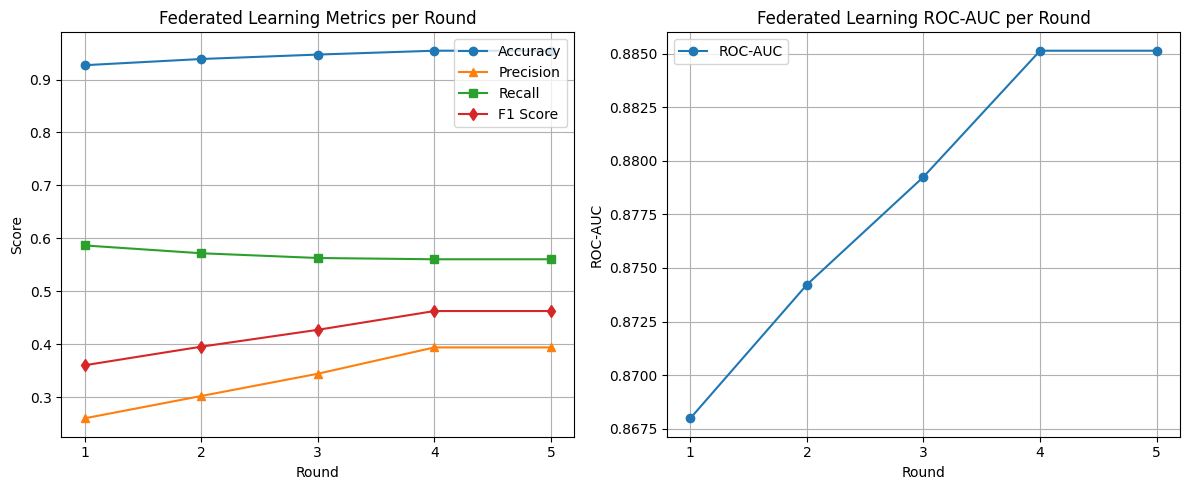

Metrics graph saved!
Federated model, threshold, and results saved successfully!

✅ Federated Learning complete!


In [ ]:


from google.colab import drive
drive.mount('/content/drive')

# =========================
# IMPORTS
# =========================
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Libraries imported successfully!")

# =========================
# LOAD PREPROCESSED DATA
# =========================
save_path = '/content/drive/MyDrive/fraud_detection_project'

X_train = np.load(f'{save_path}/X_train.npy')
X_test  = np.load(f'{save_path}/X_test.npy')
y_train = np.load(f'{save_path}/y_train.npy')
y_test  = np.load(f'{save_path}/y_test.npy')

print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("Fraud in train:", int(y_train.sum()))
print("Fraud in test :", int(y_test.sum()))
print("=" * 60)

# =========================
# CREATE 3 BANKS (MILD NON-IID)
# =========================
print("\nCreating 3 realistic banks...")

np.random.seed(42)

# Separate fraud and non-fraud
X_fraud = X_train[y_train == 1]
y_fraud = y_train[y_train == 1]

X_normal = X_train[y_train == 0]
y_normal = y_train[y_train == 0]

# Shuffle each class
fraud_idx = np.random.permutation(len(X_fraud))
normal_idx = np.random.permutation(len(X_normal))

X_fraud, y_fraud = X_fraud[fraud_idx], y_fraud[fraud_idx]
X_normal, y_normal = X_normal[normal_idx], y_normal[normal_idx]

# Mild non-IID split
# Fraud split: 35%, 33%, 32%
f1 = int(0.35 * len(X_fraud))
f2 = int(0.68 * len(X_fraud))

# Normal split: 34%, 33%, 33%
n1 = int(0.34 * len(X_normal))
n2 = int(0.67 * len(X_normal))

# Bank A
X_bank_A = np.vstack([X_fraud[:f1], X_normal[:n1]])
y_bank_A = np.concatenate([y_fraud[:f1], y_normal[:n1]])

# Bank B
X_bank_B = np.vstack([X_fraud[f1:f2], X_normal[n1:n2]])
y_bank_B = np.concatenate([y_fraud[f1:f2], y_normal[n1:n2]])

# Bank C
X_bank_C = np.vstack([X_fraud[f2:], X_normal[n2:]])
y_bank_C = np.concatenate([y_fraud[f2:], y_normal[n2:]])

def shuffle_bank(X, y):
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

X_bank_A, y_bank_A = shuffle_bank(X_bank_A, y_bank_A)
X_bank_B, y_bank_B = shuffle_bank(X_bank_B, y_bank_B)
X_bank_C, y_bank_C = shuffle_bank(X_bank_C, y_bank_C)

X_banks = [X_bank_A, X_bank_B, X_bank_C]
y_banks = [y_bank_A, y_bank_B, y_bank_C]

print("\nBank distribution:")
for i, (Xb, yb) in enumerate(zip(X_banks, y_banks)):
    print(f"Bank {chr(65+i)}: {Xb.shape} | Fraud: {int(yb.sum())} | Not Fraud: {len(yb)-int(yb.sum())}")

# =========================
# LOCAL TRAINING FUNCTION
# =========================
def train_local_model(X_local, y_local, round_num=1):
    """
    Balanced Random Forest for local bank training
    """
    model = RandomForestClassifier(
        n_estimators=min(60 + round_num * 15, 120),
        max_depth=min(8 + round_num, 12),
        min_samples_split=12,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        max_features='sqrt',
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_local, y_local)
    return model

print("\nLocal model training ready!")

# =========================
# FEDERATED PREDICTION FUNCTION
# =========================
def federated_predict(bank_models, X_input, threshold=0.46):
    all_probs = []

    for model in bank_models:
        probs = model.predict_proba(X_input)[:, 1]
        all_probs.append(probs)

    # Weighted average by local data size
    bank_sizes = [len(y_bank_A), len(y_bank_B), len(y_bank_C)]
    weights = np.array(bank_sizes) / np.sum(bank_sizes)

    avg_probs = np.average(all_probs, axis=0, weights=weights)
    predictions = (avg_probs >= threshold).astype(int)

    return predictions, avg_probs

print("Federated prediction ready!")

# =========================
# FEDERATED TRAINING LOOP
# =========================
print("\nStarting Federated Learning...")
print("=" * 60)

NUM_ROUNDS = 5
NUM_BANKS = 3
THRESHOLD = 0.46   # Balanced threshold

round_results = []
best_f1 = 0
best_models = None
best_pred = None
best_prob = None
best_round = None

start_time = time.time()

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\nRound {round_num}/{NUM_ROUNDS}")
    print("-" * 40)

    bank_models = []

    for bank_id in range(NUM_BANKS):
        model = train_local_model(
            X_banks[bank_id],
            y_banks[bank_id],
            round_num
        )
        bank_models.append(model)

        print(f"  Bank {chr(65 + bank_id)} trained successfully")

    y_pred, y_prob = federated_predict(bank_models, X_test, THRESHOLD)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    round_results.append({
        'round': round_num,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'predicted_fraud': int(y_pred.sum())
    })

    print(f"  Accuracy        : {round(accuracy, 4)}")
    print(f"  Precision       : {round(precision, 4)}")
    print(f"  Recall          : {round(recall, 4)}")
    print(f"  F1 Score        : {round(f1, 4)}")
    print(f"  ROC-AUC         : {round(roc_auc, 4)}")
    print(f"  Predicted Fraud : {int(y_pred.sum())}")

    # Probability sanity check
    print("  Probability Stats:")
    print(f"    Min   : {round(np.min(y_prob), 4)}")
    print(f"    25%   : {round(np.percentile(y_prob, 25), 4)}")
    print(f"    50%   : {round(np.percentile(y_prob, 50), 4)}")
    print(f"    75%   : {round(np.percentile(y_prob, 75), 4)}")
    print(f"    Max   : {round(np.max(y_prob), 4)}")
    print(f"    Mean  : {round(np.mean(y_prob), 4)}")

    if f1 > best_f1:
        best_f1 = f1
        best_models = bank_models
        best_pred = y_pred.copy()
        best_prob = y_prob.copy()
        best_round = round_num

total_time = time.time() - start_time

# =========================
# FINAL RESULTS
# =========================
final = max(round_results, key=lambda x: x['f1'])
y_pred = best_pred
y_prob = best_prob
bank_models = best_models

print("\n" + "=" * 65)
print("      FEDERATED LEARNING FINAL RESULTS")
print("=" * 65)
print(f"Best Round        : {best_round}")
print(f"Rounds completed  : {NUM_ROUNDS}")
print(f"Banks involved    : {NUM_BANKS}")
print(f"Threshold Used    : {THRESHOLD}")
print(f"Accuracy          : {round(final['accuracy'], 4)}")
print(f"Precision         : {round(final['precision'], 4)}")
print(f"Recall            : {round(final['recall'], 4)}")
print(f"F1 Score          : {round(final['f1'], 4)}")
print(f"ROC-AUC           : {round(final['roc_auc'], 4)}")
print(f"Predicted Fraud   : {final['predicted_fraud']}")
print(f"Actual Fraud      : {int(y_test.sum())}")
print(f"Training Time     : {round(total_time, 2)} sec")
print("=" * 65)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

# =========================
# FINAL SANITY CHECK
# =========================
print("\n" + "=" * 60)
print("FINAL SANITY CHECK")
print("=" * 60)
print("Actual Fraud in test    :", int(y_test.sum()))
print("Predicted Fraud in test :", int(y_pred.sum()))
print("Predicted Not Fraud     :", int(len(y_pred) - y_pred.sum()))
print("=" * 60)

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Not Fraud', 'Fraud'],
    yticklabels=['Not Fraud', 'Fraud']
)

plt.title(f'Federated Learning Confusion Matrix (Threshold = {THRESHOLD})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{save_path}/federated_confusion_matrix.png')
plt.show()

print("Confusion matrix saved!")

# =========================
# METRICS OVER ROUNDS
# =========================
rounds     = [r['round'] for r in round_results]
accuracies = [r['accuracy'] for r in round_results]
precisions = [r['precision'] for r in round_results]
recalls    = [r['recall'] for r in round_results]
f1_scores  = [r['f1'] for r in round_results]
roc_aucs   = [r['roc_auc'] for r in round_results]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rounds, accuracies, marker='o', label='Accuracy')
plt.plot(rounds, precisions, marker='^', label='Precision')
plt.plot(rounds, recalls, marker='s', label='Recall')
plt.plot(rounds, f1_scores, marker='d', label='F1 Score')
plt.xlabel('Round')
plt.ylabel('Score')
plt.title('Federated Learning Metrics per Round')
plt.legend()
plt.grid(True)
plt.xticks(rounds)

plt.subplot(1, 2, 2)
plt.plot(rounds, roc_aucs, marker='o', label='ROC-AUC')
plt.xlabel('Round')
plt.ylabel('ROC-AUC')
plt.title('Federated Learning ROC-AUC per Round')
plt.legend()
plt.grid(True)
plt.xticks(rounds)

plt.tight_layout()
plt.savefig(f'{save_path}/federated_learning_metrics.png')
plt.show()

print("Metrics graph saved!")

# =========================
# SAVE MODELS + RESULTS
# =========================
with open(f'{save_path}/federated_model.pkl', 'wb') as f:
    pickle.dump(bank_models, f)

with open(f'{save_path}/federated_threshold.pkl', 'wb') as f:
    pickle.dump(THRESHOLD, f)

with open(f'{save_path}/federated_results.pkl', 'wb') as f:
    pickle.dump({
        'Accuracy': final['accuracy'],
        'Precision': final['precision'],
        'Recall': final['recall'],
        'F1 Score': final['f1'],
        'ROC-AUC': final['roc_auc'],
        'Predicted Fraud': final['predicted_fraud'],
        'Actual Fraud': int(y_test.sum()),
        'Train Time': round(total_time, 2),
        'Threshold': THRESHOLD,
        'Best Round': best_round
    }, f)

print("Federated model, threshold, and results saved successfully!")
print("\n✅ Federated Learning complete!")